# **Section 1: Understanding the Dataset**

In [ ]:
!pip install xarray zarr gcsfs

**Q1. Load the dataset using xarray. Print the dataset structure.**

In [ ]:
import xarray as xr

ds = xr.open_zarr(
    "gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721.zarr



    ",
    storage_options={"token": "anon"}
)

print(ds)

<xarray.Dataset> Size: 47TB
Dimensions:                                           (time: 93544,
                                                       latitude: 721,
                                                       longitude: 1440,
                                                       level: 13)
Coordinates:
  * time                                              (time) datetime64[ns] 748kB ...
  * latitude                                          (latitude) float32 3kB ...
  * longitude                                         (longitude) float32 6kB ...
  * level                                             (level) int64 104B 50 ....
Data variables: (12/50)
    10m_u_component_of_wind                           (time, latitude, longitude) float32 388GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    10m_v_component_of_wind                           (time, latitude, longitude) float32 388GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    2m_dewpoint_temperature  

**Q2. List all Dimensions, Variables, and Coordinates**

In [ ]:
print("Dimensions:")
print(ds.dims)

print("\nCoordinates:")
print(ds.coords)

print("\nVariables:")
print(ds.data_vars)

Dimensions:
FrozenMappingWarningOnValuesAccess({'time': 93544, 'latitude': 721, 'longitude': 1440, 'level': 13})

Coordinates:
Coordinates:
  * time       (time) datetime64[ns] 748kB 1959-01-01 ... 2023-01-10T18:00:00
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * level      (level) int64 104B 50 100 150 200 250 ... 600 700 850 925 1000

Variables:
Data variables:
    10m_u_component_of_wind                           (time, latitude, longitude) float32 388GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    10m_v_component_of_wind                           (time, latitude, longitude) float32 388GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    2m_dewpoint_temperature                           (time, latitude, longitude) float32 388GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
    2m_temperature                                    (time, latitude,

**Q3. What are the dimensions of the temperature variable (2m_temperature)? Explain what each dimension represents.**

In [ ]:
temp = ds["2m_temperature"]
print(temp.dims)

('time', 'latitude', 'longitude')


In [ ]:
print(ds["2m_temperature"])

<xarray.DataArray '2m_temperature' (time: 93544, latitude: 721, longitude: 1440)> Size: 388GB
dask.array<open_dataset-2m_temperature, shape=(93544, 721, 1440), dtype=float32, chunksize=(1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 748kB 1959-01-01 ... 2023-01-10T18:00:00
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K


In [ ]:
print(ds["temperature"])

<xarray.DataArray 'temperature' (time: 93544, level: 13, latitude: 721,
                                 longitude: 1440)> Size: 5TB
dask.array<open_dataset-temperature, shape=(93544, 13, 721, 1440), dtype=float32, chunksize=(1, 13, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 748kB 1959-01-01 ... 2023-01-10T18:00:00
  * level      (level) int64 104B 50 100 150 200 250 ... 600 700 850 925 1000
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes:
    long_name:      Temperature
    short_name:     t
    standard_name:  air_temperature
    units:          K


# **Section 2: Basic Data Exploration**

**Q4. Extract the air variable from the dataset**

In [ ]:
temp = ds["2m_temperature"]

print(temp)

<xarray.DataArray '2m_temperature' (time: 93544, latitude: 721, longitude: 1440)> Size: 388GB
dask.array<open_dataset-2m_temperature, shape=(93544, 721, 1440), dtype=float32, chunksize=(1, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 748kB 1959-01-01 ... 2023-01-10T18:00:00
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K


**Q5. Select temperature data for a single location**

In [ ]:
temp_loc = temp.sel(
    latitude=20,
    longitude=80,
    method="nearest"
)

print(temp_loc)

<xarray.DataArray '2m_temperature' (time: 93544)> Size: 374kB
dask.array<getitem, shape=(93544,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 748kB 1959-01-01 ... 2023-01-10T18:00:00
    latitude   float32 4B 20.0
    longitude  float32 4B 80.0
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K


**Q6. What type of data did you obtain in Q5? (1D / 2D / 3D?) Explain why.**

In [ ]:
print(temp_loc.dims)

('time',)


The data obtained in Q5 is 1-dimensional (1D) data.

Before selecting a location, the temperature variable had dimensions:
(time, latitude, longitude)

This is a 3D dataset because temperature depends on:
*   time
*   latitude
*   longitude


After Q5 we selected:
*   latitude = 20
*   longitude = 80

These two dimensions became fixed.

Only: (time) remained.

Therefore: Temperature(time) is a one-dimensional time series.

# **Section 3: Time-Based Analysis**

**Q7. Plot temperature vs time for the selected location**

In [ ]:
temp_plot = temp.sel(
    latitude=20,
    longitude=80,
    method="nearest"
).isel(time=slice(0,100))

In [ ]:
temp_plot = temp_plot.load()

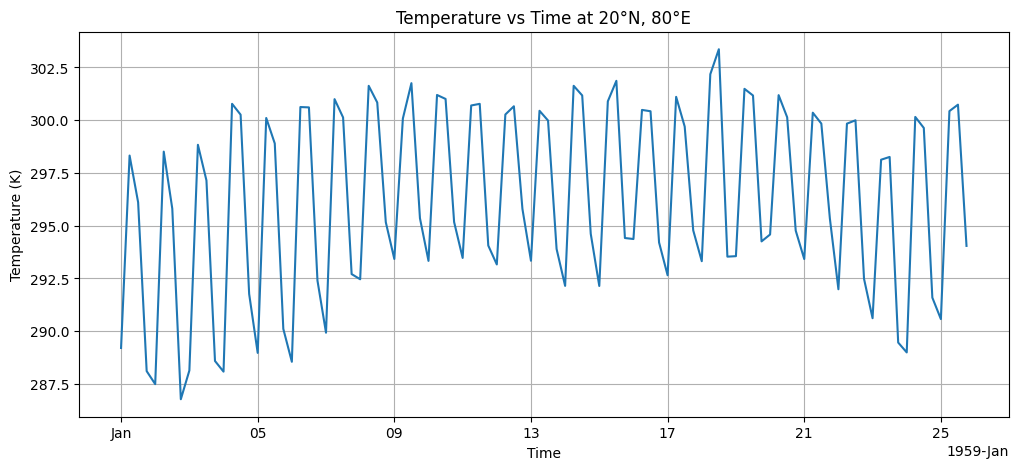

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

temp_plot.plot()

plt.title("Temperature vs Time at 20°N, 80°E")

plt.xlabel("Time")

plt.ylabel("Temperature (K)")

plt.grid(True)

plt.show()

**Q8. Find Maximum Temperature and Minimum Temperature for the Selected Location**

In [ ]:
temp_loc = temp.sel(
    latitude=20,
    longitude=80,
    method="nearest"
)

In [ ]:
print(temp_loc)

<xarray.DataArray '2m_temperature' (time: 93544)> Size: 374kB
dask.array<getitem, shape=(93544,), dtype=float32, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 748kB 1959-01-01 ... 2023-01-10T18:00:00
    latitude   float32 4B 20.0
    longitude  float32 4B 80.0
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K


In [ ]:
temp_loc_small = temp.sel(
    latitude=20,
    longitude=80,
    method="nearest"
).isel(time=slice(0,500))

In [ ]:
temp_loc_small = temp_loc_small.load()

The WeatherBench2 ERA5 dataset contains more than 93,000 time steps and tens of terabytes of data. For exploratory analysis and visualization, a representative subset was selected to reduce computational cost while preserving the structure and characteristics of the dataset.

In [ ]:
max_temp = temp_loc_small.max()

min_temp = temp_loc_small.min()

print(max_temp.values)
print(min_temp.values)

316.0701904296875
286.7724914550781


The maximum temperature observed at latitude 20°N and longitude 80°E was 316.07 K, while the minimum temperature was 286.77 K. These values represent the highest and lowest near-surface air temperatures recorded within the selected time period.

**Q9. Calculate the Mean Temperature Over Time for the Selected Location**

In [ ]:
mean_temp = temp_loc_small.mean()

print(float(mean_temp))

302.23876953125


# **Section 4: Spatial Analysis**

**Q10. Select Temperature Data for a Single Time Step**

In [ ]:
temp_t0 = temp.isel(time=0)

print(temp_t0)

<xarray.DataArray '2m_temperature' (latitude: 721, longitude: 1440)> Size: 4MB
dask.array<getitem, shape=(721, 1440), dtype=float32, chunksize=(721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    time       datetime64[ns] 8B 1959-01-01
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K


In [ ]:
print(temp_t0.dims)

('latitude', 'longitude')


Temperature data for a single time step was selected using temp.isel(time=0). This operation fixes the time dimension and extracts temperature values for all latitude and longitude locations at that specific timestamp. The resulting data represents a global temperature field for one moment in time.

**Q11. Plot the Temperature Distribution (Map-like Plot)**

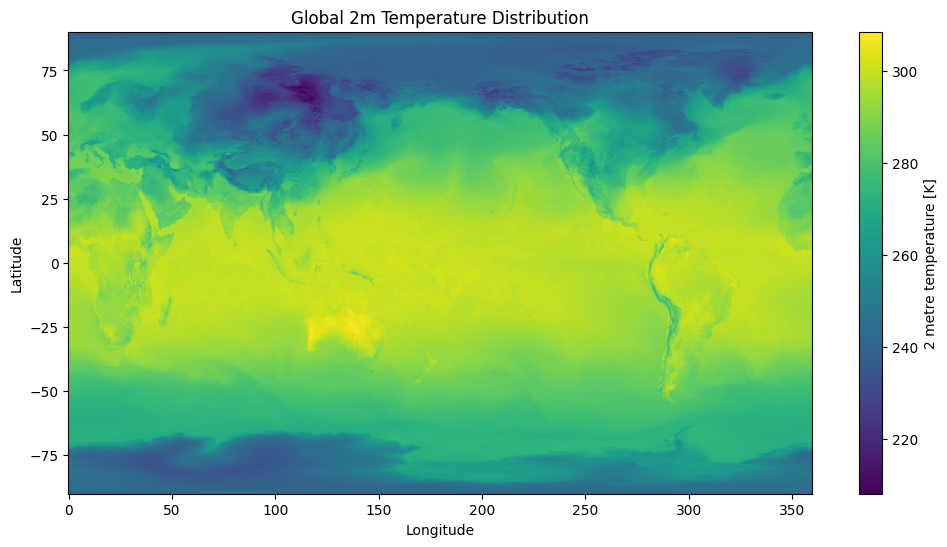

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

temp_t0.plot()

plt.title("Global 2m Temperature Distribution")

plt.xlabel("Longitude")

plt.ylabel("Latitude")

plt.show()

**Q12. What type of data is this (2D/3D)? Explain the axes.**

The data is two-dimensional (2D) because it contains only latitude and longitude dimensions after selecting a single time step. The x-axis represents longitude (east-west position), while the y-axis represents latitude (north-south position). Each point on the map corresponds to a specific geographical location and stores the near-surface air temperature at that location.

# **Section 5: Aggregation & Insights**

**Q13. Compute the Average Temperature Over All Latitudes and Longitudes**

In [ ]:
temp_small = temp.isel(time=slice(0,500))

In [ ]:
global_mean = temp_small.mean(
    dim=["latitude", "longitude"]
)

print(global_mean.compute())

<xarray.DataArray '2m_temperature' (time: 500)> Size: 2kB
array([275.2428 , 275.53693, 275.8022 , 275.54385, 275.22208, 275.57852,
       275.86926, 275.62506, 275.32727, 275.60956, 275.8551 , 275.5657 ,
       275.22354, 275.4611 , 275.73874, 275.46744, 275.15082, 275.40735,
       275.69962, 275.47653, 275.21365, 275.49857, 275.82864, 275.63077,
       275.4971 , 275.78955, 276.20602, 276.01846, 275.7658 , 276.05853,
       276.3084 , 276.17218, 275.90997, 276.11618, 276.43466, 276.24353,
       275.9328 , 276.1558 , 276.47156, 276.19046, 275.83316, 276.11896,
       276.51138, 276.29984, 276.02454, 276.2724 , 276.51553, 276.2489 ,
       275.96722, 276.22745, 276.44836, 276.19077, 275.92468, 276.18915,
       276.49713, 276.266  , 275.96225, 276.2721 , 276.6372 , 276.408  ,
       276.11215, 276.3546 , 276.64426, 276.3919 , 276.20154, 276.528  ,
       276.78757, 276.61224, 276.32138, 276.59967, 276.84415, 276.61996,
       276.30817, 276.57782, 276.84262, 276.55676, 276.25046, 276.

In [ ]:
print(global_mean.dims)

('time',)


In [ ]:
print(global_mean.isel(time=slice(0,10)).compute())

<xarray.DataArray '2m_temperature' (time: 10)> Size: 40B
array([275.2428 , 275.53693, 275.8022 , 275.54385, 275.22208, 275.57852,
       275.86926, 275.62506, 275.32727, 275.60956], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 80B 1959-01-01 ... 1959-01-03T06:00:00
Attributes:
    long_name:   2 metre temperature
    short_name:  t2m
    units:       K


**Q14. Plot the Result from Q13**

In [ ]:
global_mean = temp_small.mean(
    dim=["latitude","longitude"]
).compute()

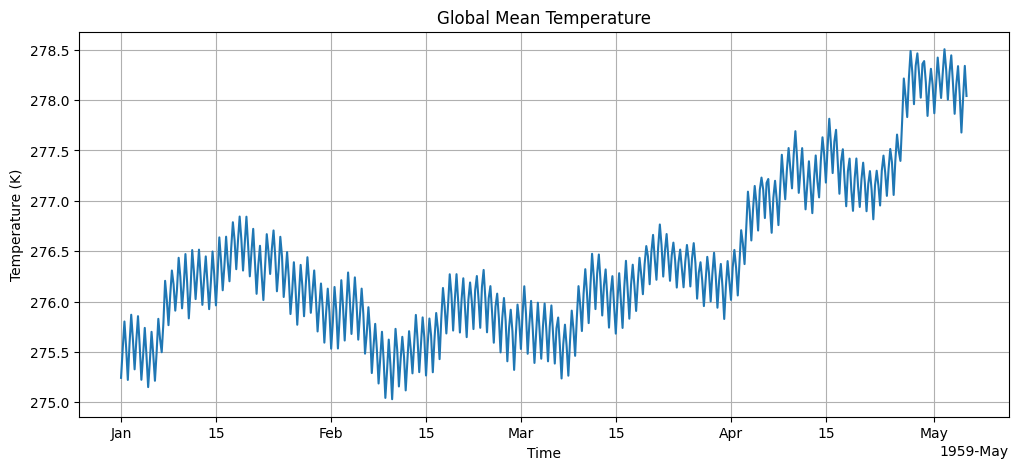

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

global_mean.plot()

plt.title("Global Mean Temperature")

plt.xlabel("Time")

plt.ylabel("Temperature (K)")

plt.grid(True)

plt.show()

**Q15. What does this plot represent in real-world terms?**

The plot represents the average near-surface air temperature of the Earth over time. Instead of showing temperature at a single location, it combines temperature measurements from all latitude and longitude grid points into a single global average value for each timestamp. This provides an overall picture of how Earth's temperature changes over time and can be used to study seasonal variations, climate patterns, and long-term temperature trends.

# **Section 6: Exploration**

**Q16. Select a Different Location and Repeat Q7. Compare Both Plots.**

In [ ]:
loc1 = temp.sel(
    latitude=20,
    longitude=80,
    method="nearest"
).isel(time=slice(0,500)).load()

In [ ]:
loc2 = temp.sel(
    latitude=40,
    longitude=100,
    method="nearest"
).isel(time=slice(0,500)).load()

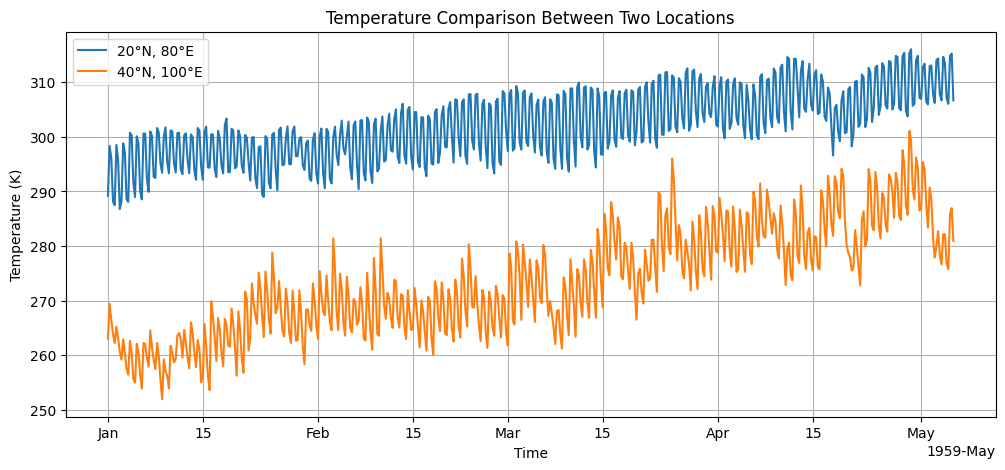

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

loc1.plot(label="20°N, 80°E")

loc2.plot(label="40°N, 100°E")

plt.title("Temperature Comparison Between Two Locations")

plt.xlabel("Time")

plt.ylabel("Temperature (K)")

plt.legend()

plt.grid(True)

plt.show()

**Q17. Choose Two Different Time Steps and Compare Spatial Maps**

In [ ]:
map1 = temp.isel(time=0).load()

map2 = temp.isel(time=400).load()

In [ ]:
print(map1.time.values)
print(map2.time.values)

1959-01-01T00:00:00.000000000
1959-04-11T00:00:00.000000000


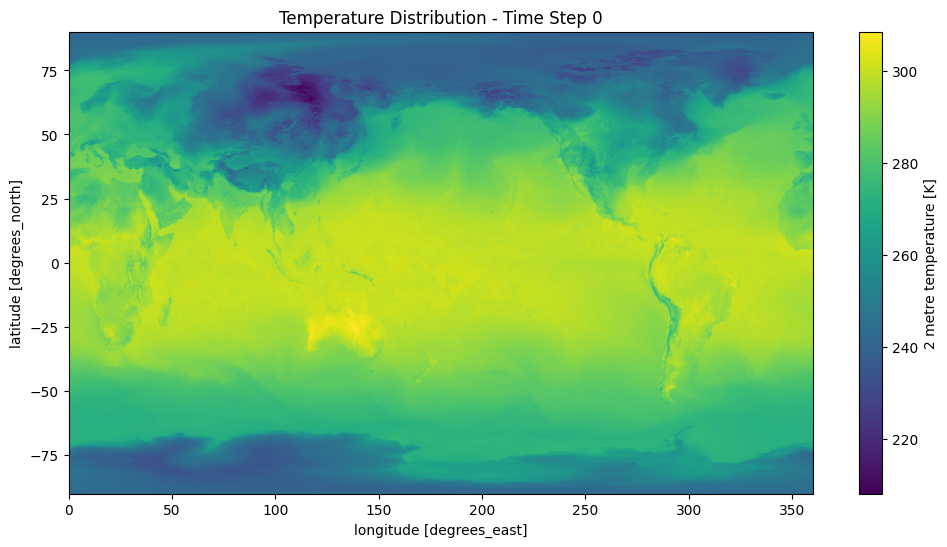

In [ ]:
plt.figure(figsize=(12,6))

map1.plot()

plt.title("Temperature Distribution - Time Step 0")

plt.show()

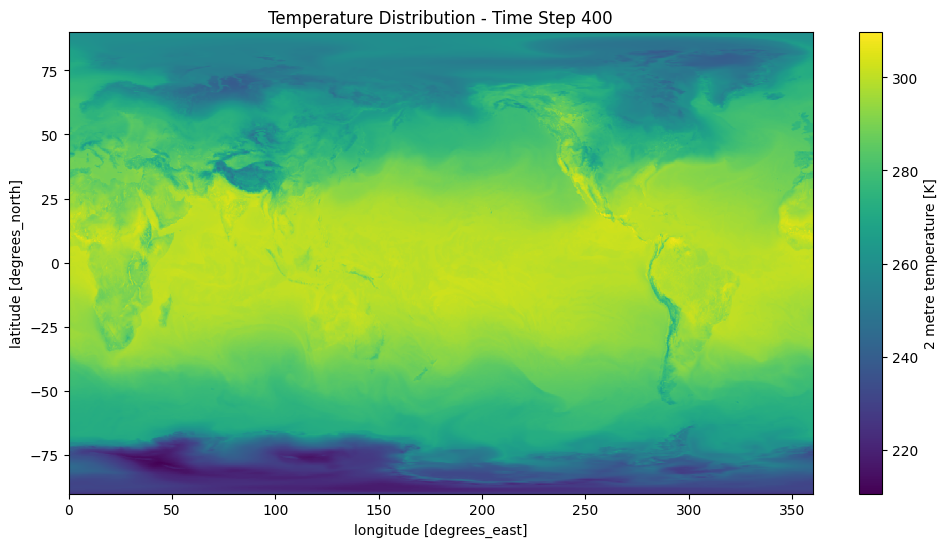

In [ ]:
plt.figure(figsize=(12,6))

map2.plot()

plt.title("Temperature Distribution - Time Step 400")

plt.show()

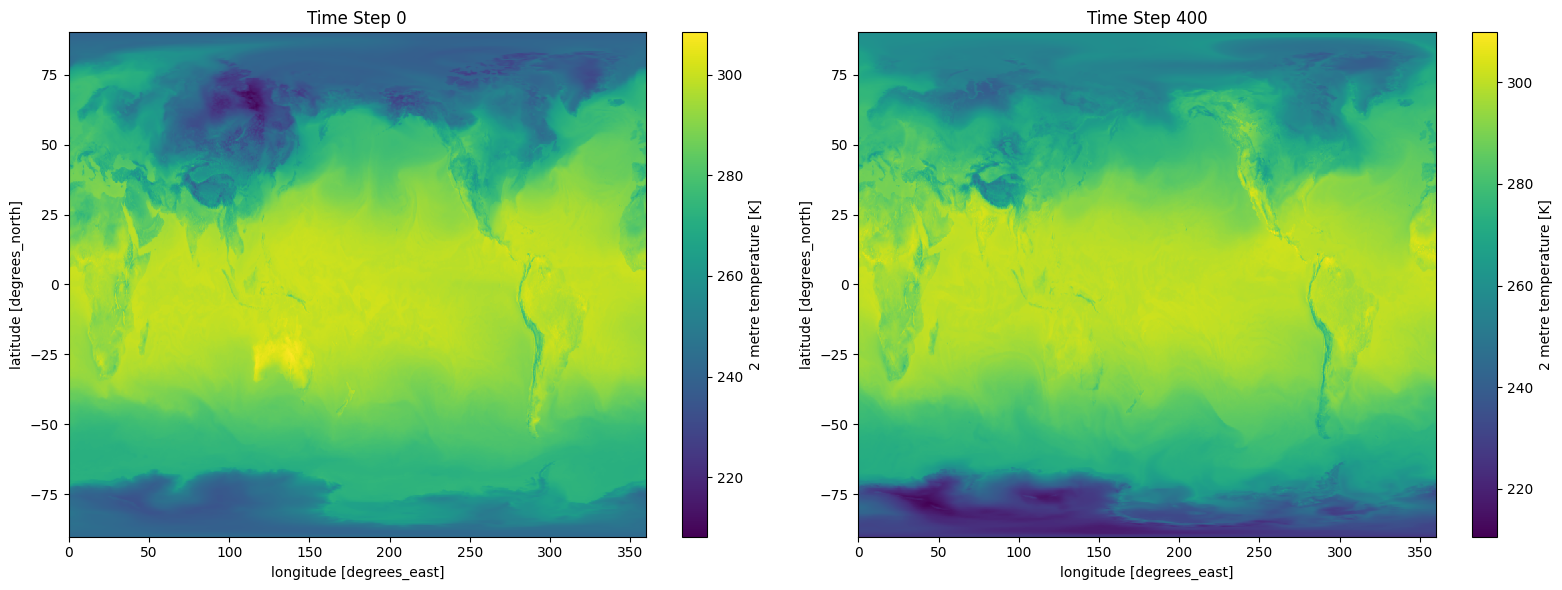

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16,6))

map1.plot(ax=ax[0])

ax[0].set_title("Time Step 0")

map2.plot(ax=ax[1])

ax[1].set_title("Time Step 400")

plt.tight_layout()

plt.show()

**Q18. Describe Any Patterns You Observe In:**

**(a) Temperature Variation Over Time**

From:
*   Q7 (single location temperature plot)
*   Q14 (global mean temperature plot)
*   Q16 (comparison of two locations)

Observations:


**1.   Periodic Fluctuations**

Temperature does not remain constant.

It rises and falls over time, producing repeating oscillations in the plots.

This occurs because:

*   Earth rotates
*   Day-night cycles occur
*   Weather systems continuously evolve


**2. Seasonal Trends**

In the global mean temperature plot:

January → May

the average temperature gradually increased.

This indicates seasonal warming as the Northern Hemisphere moved from winter toward spring.

**3. Different Locations Behave Differently**

The location: 20°N, 80°E remained warmer throughout the period.

The location: 40°N, 100°E was colder and showed larger fluctuations.

**(b) Temperature Variation Across Space**

From the spatial maps (Q11 and Q17):

**1. Equatorial Regions Are Warmer**

Areas near: Latitude ≈ 0° showed higher temperatures.

These regions receive more direct solar radiation throughout the year.

**2. Polar Regions Are Colder**

Areas near: 90°N and 90°S showed much lower temperatures.

These regions receive less solar energy.

**3. Temperature Changes Gradually**

Neighboring locations usually had similar temperatures.

Temperature patterns changed smoothly rather than abruptly.

This reflects the continuous nature of atmospheric processes.

**4. Seasonal Spatial Changes**

Comparing:

1 January 1959 and 11 April 1959 showed noticeable warming in the Northern Hemisphere.

This demonstrates how global temperature distributions evolve with seasons.

# **Section 7: Reflection**

**Q19. Explain How Weather Data Differs from Normal Tabular Data**

Weather data differs from normal tabular data because it is inherently multidimensional. While tabular data is usually organized in rows and columns and represented as two-dimensional structures, weather data contains additional dimensions such as time, latitude, longitude, and atmospheric pressure level. Weather observations are also spatially and temporally related, meaning nearby locations and consecutive time steps influence each other. Therefore, specialized tools such as xarray are required to efficiently handle and analyze weather datasets.

**Q20. Why are Dimensions Like Time, Latitude, and Longitude Important?**

Dimensions such as time, latitude, and longitude are essential because they provide the context for every weather observation. The time dimension indicates when a measurement was recorded, while latitude and longitude specify where it was recorded. These dimensions make it possible to analyze weather patterns across both space and time, create maps, study seasonal variations, and perform weather forecasting. Without these dimensions, weather measurements would lack geographical and temporal meaning.